Analise o conjunto de dados `titanic`. Estes dados contêm informações sobre os passageiros do Titanic, incluindo o valor que pagaram pela passagem e se sobreviveram ou não (nota: este é um subconjunto dos dados completos disponíveis). Para praticar as habilidades aprendidas em aula, vamos investigar se existe uma associação entre a tarifa que um passageiro pagou ( `Fare`) e se ele sobreviveu ou não (`Survived`, que é igual a `0` se o passageiro morreu e `1` se sobreviveu):

1. Calcule  a diferença na tarifa **média** e **mediana** paga pelos que sobreviveram e pelos que morreram. Qual grupo pagou uma tarifa média e em mediana mais alta?
3. Crie gráficos boxplot relacionando as variáveis de tarifas e sobrevivência. Agora que você pode ver a distribuição dos dados, as diferenças médias/medianas parecem relativamente pequenas ou grandes?
4. Crie histogramas sobrepostos de tarifas por sobrevivência. Isso fornece alguma informação adicional?

### Exercícios Adicionais

4. Qual a proporção de sobreviventes entre homens e mulheres? Apresente os resultados em forma de gráfico de barras.

5. Qual a idade média dos passageiros por classe `(Pclass)`? Alguma classe apresenta um grupo significativamente mais jovem?

6. Quantos passageiros embarcaram em cada um dos portos `(Embarked)` e qual foi a taxa de sobrevivência em cada porto?

7. Crie uma nova coluna chamada FaixaEtaria que classifique os passageiros em:

- Criança (idade < 12),
- Adolescente (12–17),
- Adulto (18–59),
- Idoso (60+).

Em seguida, calcule a taxa de sobrevivência para cada faixa etária.

8. Qual o ticket médio `(Fare)` pago por passageiros em cada classe `(Pclass)`? Existe uma relação entre o valor pago e a sobrevivência?

9. Quantos passageiros estavam viajando sozinhos (ou seja, `SibSp` = 0 e `Parch` = 0)? Qual foi a taxa de sobrevivência desse grupo comparada aos que estavam acompanhados?

10. Crie um gráfico de dispersão (scatter plot) relacionando idade e tarifa paga (`Fare`), destacando os sobreviventes com uma cor diferente.

In [25]:
#Ex-1
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('titanic.csv')

fare_stats = df.groupby('Survived')['Fare'].agg(['mean', 'median'])
print(fare_stats)

#Os sobreviventes em média pagaram um tarifa mais alta

               mean  median
Survived                   
0         22.117887    10.5
1         48.395408    26.0


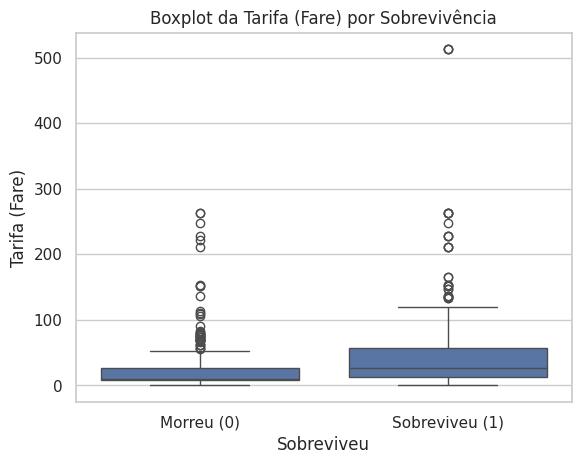

In [10]:
#Ex-2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('titanic.csv')

sns.boxplot(x='Survived', y='Fare', data=df)
plt.xticks([0, 1], ['Morreu (0)', 'Sobreviveu (1)'])
plt.title('Boxplot da Tarifa (Fare) por Sobrevivência')
plt.xlabel('Sobreviveu')
plt.ylabel('Tarifa (Fare)')
plt.show()

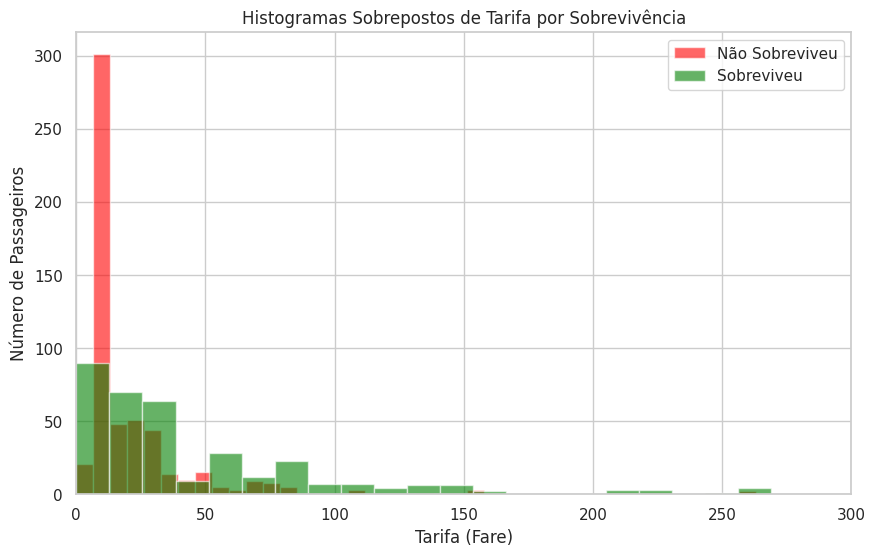

In [13]:
#Ex-3
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('titanic.csv')

plt.figure(figsize=(10,6))
plt.hist(df[df['Survived'] == 0]['Fare'], bins=40, alpha=0.6, label='Não Sobreviveu', color='red')
plt.hist(df[df['Survived'] == 1]['Fare'], bins=40, alpha=0.6, label='Sobreviveu', color='green')

plt.xlabel('Tarifa (Fare)')
plt.ylabel('Número de Passageiros')
plt.title('Histogramas Sobrepostos de Tarifa por Sobrevivência')
plt.legend()
plt.xlim(0, 300)
plt.grid(True)
plt.show()
#Passageiros que pagaram mais tinham maior chance de sobreviver.

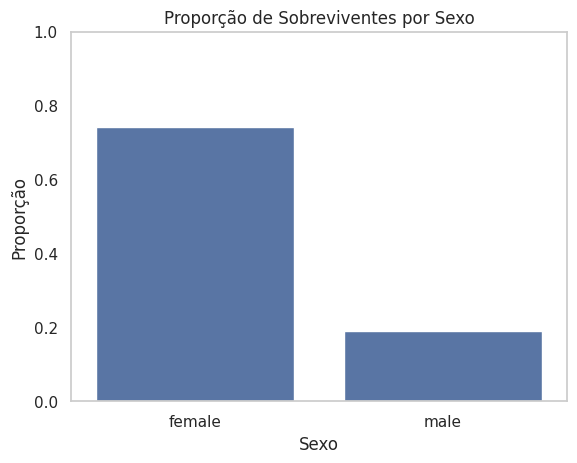

In [16]:
#Ex-4
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('titanic.csv')

survival_rate = df.groupby('Sex')['Survived'].mean().reset_index()
survival_rate.columns = ['Sexo', 'Proporcao']

sns.barplot(data=survival_rate, x='Sexo', y='Proporcao')
plt.title('Proporção de Sobreviventes por Sexo')
plt.ylabel('Proporção')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()
#Política de “mulheres e crianças primeiro” provavelmente influenciou diretamente o resultado, fazendo com que mulheres tivessem maior taxa de sobrevivência

In [18]:
#Ex-5
import pandas as pd

df = pd.read_csv('titanic.csv')

idade_media = df.groupby('Pclass')['Age'].mean().reset_index()
idade_media.columns = ['Classe', 'Idade Média']

print(idade_media)
#Passageiros da 3ª classe eram, em média, mais jovens

   Classe  Idade Média
0       1    38.233441
1       2    29.877630
2       3    25.140620


In [19]:
#Ex-6
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('titanic.csv')

embarked_counts = df['Embarked'].value_counts(dropna=False)
survival_by_embarked = df.groupby('Embarked')['Survived'].mean()

print("Passageiros por porto de embarque:\n", embarked_counts)
print("\nTaxa de sobrevivência por porto:\n", survival_by_embarked)
#O local de embarque parece ter relação indireta com classe e localização no navio, o que afeta a chance de sobrevivência.

Passageiros por porto de embarque:
 Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

Taxa de sobrevivência por porto:
 Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


In [20]:
#Ex-7
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('titanic.csv')

def classificar_faixa_etaria(idade):
    if pd.isnull(idade):
        return 'Desconhecido'
    elif idade < 12:
        return 'Criança'
    elif idade < 18:
        return 'Adolescente'
    elif idade < 60:
        return 'Adulto'
    else:
        return 'Idoso'

df['FaixaEtaria'] = df['Age'].apply(classificar_faixa_etaria)
faixa_survival = df.groupby('FaixaEtaria')['Survived'].mean()

print("\nTaxa de sobrevivência por faixa etária:\n", faixa_survival)

#Crianças tiveram a maior taxa de sobrevivência


Taxa de sobrevivência por faixa etária:
 FaixaEtaria
Adolescente     0.488889
Adulto          0.386087
Criança         0.573529
Desconhecido    0.293785
Idoso           0.269231
Name: Survived, dtype: float64


In [21]:
#Ex-8
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('titanic.csv')

fare_by_class = df.groupby('Pclass')['Fare'].mean()
survival_by_class = df.groupby('Pclass')['Survived'].mean()

print("\nTarifa média por classe:\n", fare_by_class)
print("\nTaxa de sobrevivência por classe:\n", survival_by_class)

#Passageiros da 1ª classe pagaram mais e tiveram maior taxa de sobrevivência


Tarifa média por classe:
 Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

Taxa de sobrevivência por classe:
 Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [22]:
#Ex-9
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('titanic.csv')

df['ViajandoSozinho'] = ((df['SibSp'] == 0) & (df['Parch'] == 0))

solo_counts = df['ViajandoSozinho'].value_counts()
solo_survival = df.groupby('ViajandoSozinho')['Survived'].mean()

print("\nPassageiros sozinhos:\n", solo_counts)
print("\nTaxa de sobrevivência:\n", solo_survival)
#Passageiros acompanhados tinham mais chances de sobreviver.


Passageiros sozinhos:
 ViajandoSozinho
True     537
False    354
Name: count, dtype: int64

Taxa de sobrevivência:
 ViajandoSozinho
False    0.505650
True     0.303538
Name: Survived, dtype: float64


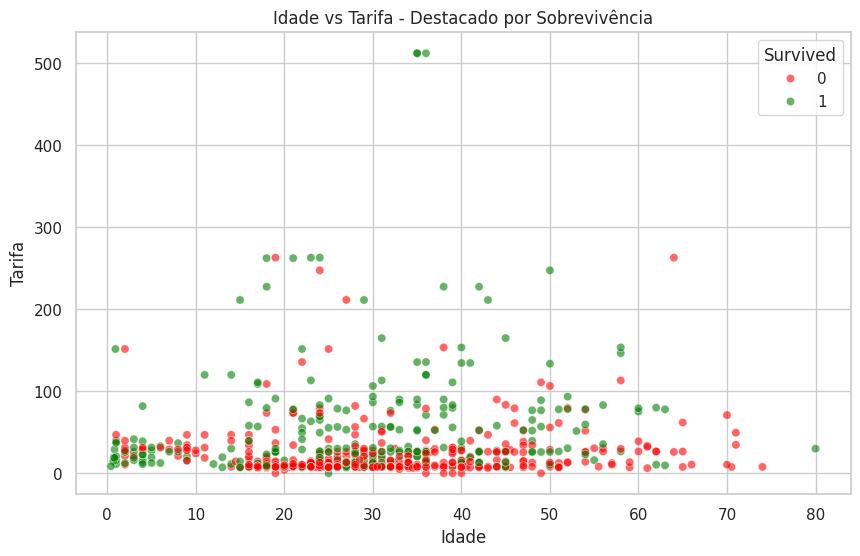

In [24]:
#Ex-10
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('titanic.csv')

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived', palette={0: 'red', 1: 'green'}, alpha=0.6)
plt.title('Idade vs Tarifa - Destacado por Sobrevivência')
plt.xlabel('Idade')
plt.ylabel('Tarifa')
plt.grid(True)
plt.show()